In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/68 (12).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/88 (6).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/66 (21) - Copy.jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/93 (17).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/70 (37).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/75 (18).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/66 (15) - Copy.jpg
/kaggle/input/datasets/iashiqul/brain-stro

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
dataset_path = "/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image"


train_path = os.path.join(dataset_path, "Train")
val_path = os.path.join(dataset_path, "Validation")
test_path = os.path.join(dataset_path, "Test")

In [4]:
print("Train:", os.listdir(train_path))
print("Validation:", os.listdir(val_path))
print("Test:", os.listdir(test_path))

Train: ['Stroke', 'Normal']
Validation: ['Stroke', 'Normal']
Test: ['Stroke', 'Normal']


### Class Distribution Analysis

The dataset shows a moderate class imbalance across the training, validation, and test sets. The **Normal** class contains more samples than the **Stroke** class, which may bias the model toward predicting the majority class.

In medical image classification tasks, relying solely on **accuracy** can be misleading when the dataset is imbalanced. Therefore, model evaluation should also include metrics such as **Precision**, **Recall**, **F1-Score**, and **ROC-AUC** to provide a more reliable assessment of performance.

During the model development phase, techniques such as **class weighting** or **data augmentation** may be considered to reduce the impact of class imbalance and improve the model's ability to detect stroke cases.


In [5]:
import pandas as pd

splits = {
    "Train": train_path,
    "Validation": val_path,
    "Test": test_path
}

data = []

for split_name, split_path in splits.items():
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            image_count = len(os.listdir(class_path))
            data.append({
                "Split": split_name,
                "Class": class_name,
                "Images": image_count
            })

df = pd.DataFrame(data)

df

,Split,Class,Images
0,Train,Stroke,756
1,Train,Normal,1087
2,Validation,Stroke,78
3,Validation,Normal,157
4,Test,Stroke,130
5,Test,Normal,307


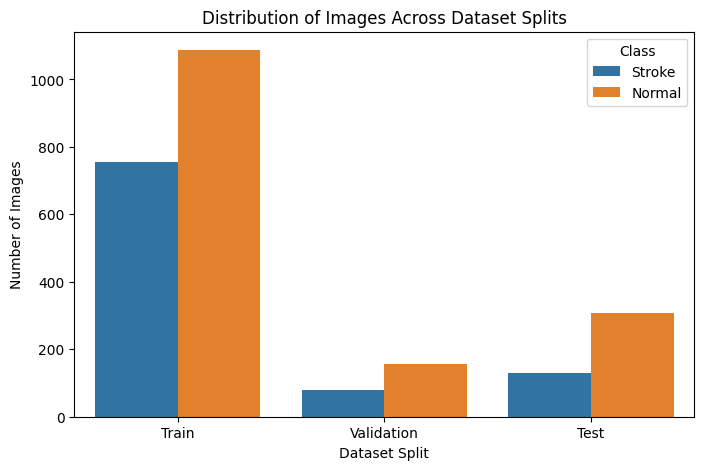

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Split",
    y="Images",
    hue="Class"
)

plt.title("Distribution of Images Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.legend(title="Class")
plt.show()

### Sample Image Visualization

Random samples from both the **Normal** and **Stroke** classes were visualized to inspect the dataset qualitatively. The images are brain CT scans with consistent grayscale appearance and no obvious corrupted samples.

Although the scans exhibit slight variations in slice position and head size, such differences are expected in medical imaging datasets. These observations suggest that the dataset is suitable for further preprocessing and model training.

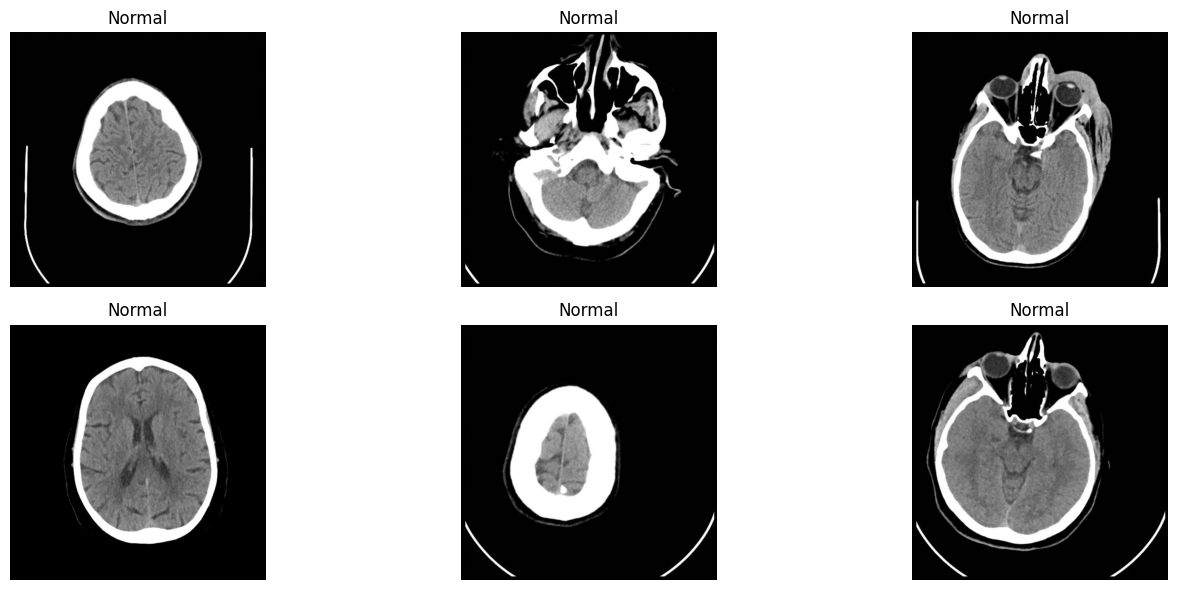

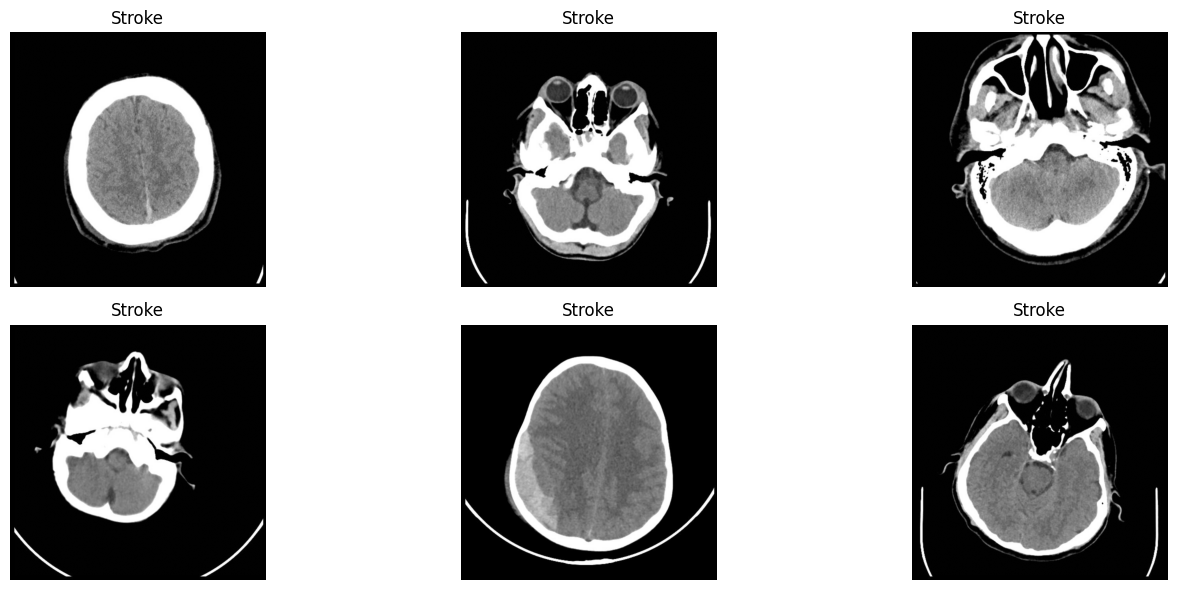

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

def show_samples(folder_path, class_name, num_images=6):
    class_path = os.path.join(folder_path, class_name)

    image_files = random.sample(os.listdir(class_path), num_images)

    plt.figure(figsize=(15, 6))

    for i, image_name in enumerate(image_files):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(train_path, "Normal")
show_samples(train_path, "Stroke")

### Image Dimension Analysis

The image dimensions were analyzed to verify the consistency of the dataset. All training images have an identical resolution of **650 × 650 pixels**, indicating that the dataset is well standardized.

Since all images share the same dimensions, no additional resizing is required for consistency. However, the images will be resized to the input size expected by the selected deep learning model during preprocessing.

In [8]:
from PIL import Image

image_sizes = []

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        with Image.open(image_path) as img:
            image_sizes.append(img.size)   # (width, height)

from collections import Counter

Counter(image_sizes).most_common(10)

[((650, 650), 1843)]

### Color Channel Analysis

The images were inspected to determine their color format. All CT scan images are stored in **grayscale mode (L)**, meaning that each image contains a single intensity channel rather than three RGB channels.

This is expected for medical CT images, as grayscale intensity values carry the relevant anatomical information. During preprocessing, the images will be converted to the input format required by the selected pre-trained deep learning model while preserving their visual content.

In [9]:
sample_image = Image.open(
    os.path.join(train_path, "Normal", os.listdir(os.path.join(train_path, "Normal"))[0])
)

print("Image Mode:", sample_image.mode)
print("Image Size:", sample_image.size)

Image Mode: L
Image Size: (650, 650)


### Corrupted Image Inspection

To ensure data quality, all images were checked using the Pillow library to verify their integrity and detect any corrupted or unreadable files.

The inspection confirmed that no corrupted images were found in the training, validation, or test sets. Therefore, the dataset is clean and ready for preprocessing and model development.

In [10]:
from PIL import Image
import os

def check_corrupted_images(folder_path):
    corrupted_images = []

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                with Image.open(image_path) as img:
                    img.verify()   # Verify image integrity
            except Exception:
                corrupted_images.append(image_path)

    return corrupted_images

train_corrupted = check_corrupted_images(train_path)
val_corrupted = check_corrupted_images(val_path)
test_corrupted = check_corrupted_images(test_path)

print(f"Train Corrupted Images: {len(train_corrupted)}")
print(f"Validation Corrupted Images: {len(val_corrupted)}")
print(f"Test Corrupted Images: {len(test_corrupted)}")

Train Corrupted Images: 0
Validation Corrupted Images: 0
Test Corrupted Images: 0
